# Artificial Intelligence in Medicine
## NOTEBOOK 2: Simülasyon Ortamı + REINFORCE Eğitimi

**Ön koşul:** Notebook 1'den üretilen `processed_data.npz` ve `scaler.pkl` dosyaları bu notebook ile aynı dizinde olmalıdır.

---
**Algoritma:** REINFORCE (Policy Gradient)  
**Ortam:** Custom OpenAI Gymnasium — `MedicalEnv`  
**Framework:** PyTorch + CUDA

## 0 — Kurulum

In [12]:
!pip install gymnasium plotly -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import gymnasium as gym
from gymnasium import spaces

import warnings, os, pickle, zipfile
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Cihaz: {device}')

Cihaz: cuda


## 1 — İşlenmiş Veriyi Yükle

In [13]:
from google.colab import drive
import os
import numpy as np

drive.mount('/content/drive')

# Otomatik dosya bulma
data_file = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'processed_data.npz' in files:
        data_file = os.path.join(root, 'processed_data.npz')
        break

if data_file is None:
    raise FileNotFoundError("processed_data.npz Drive'da bulunamadı!")

print("Dosya bulundu:", data_file)

data = np.load(data_file, allow_pickle=True)

X            = data['X'].astype(np.float32)
y            = data['y'].astype(np.int64)
states       = data['states'].astype(np.float32)
actions      = data['actions'].astype(np.int64)
rewards      = data['rewards'].astype(np.float32)
next_states  = data['next_states'].astype(np.float32)
feature_cols = list(data['feature_cols'])
NUM_ACTIONS  = int(data['num_actions'][0])
STATE_DIM    = int(data['state_dim'][0])

ACTION_NAMES = ['Azalt (dec)', 'Sabit Tut (keep)', 'Artır (inc)']

# (s, a, r, s') tuple listesi
trajectories = list(zip(states, actions, rewards, next_states))

print(f'   Toplam yörünge adımı : {len(trajectories):,}')
print(f'   Durum boyutu (state_dim) : {STATE_DIM}')
print(f'   Eylem sayısı         : {NUM_ACTIONS}')
print(f'   Özellikler           : {feature_cols}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dosya bulundu: /content/drive/MyDrive/processed_data.npz
   Toplam yörünge adımı : 99,999
   Durum boyutu (state_dim) : 15
   Eylem sayısı         : 3
   Özellikler           : [np.str_('year'), np.str_('gender'), np.str_('age'), np.str_('location'), np.str_('race:AfricanAmerican'), np.str_('race:Asian'), np.str_('race:Caucasian'), np.str_('race:Hispanic'), np.str_('race:Other'), np.str_('hypertension'), np.str_('heart_disease'), np.str_('smoking_history'), np.str_('bmi'), np.str_('hbA1c_level'), np.str_('blood_glucose_level')]


## 2 — Simülasyon Ortamı (MedicalEnv)

In [14]:
def compute_reward(action, last_action=None):
    """
    Ödül fonksiyonu — ödev tablosuna göre:
        +1.0  → Hedef aralıkta kalma  (sabit tut)
        -1.0  → Hipoglisemi riski     (azalt)
        -2.0  → Hiperglisemi          (artır)
        -0.1  → Aşırı doz cezası      (art arda artır)
    """
    reward_map = {0: -1.0, 1: 1.0, 2: -2.0}
    r = reward_map.get(action, 0.0)
    if action == 2 and last_action == 2:
        r -= 0.1
    return r


class MedicalEnv(gym.Env):
    """
    Hiperglisemi Hastası İnsülin Doz Optimizasyon Ortamı
    ─────────────────────────────────────────────────────
    OpenAI Gymnasium arayüzüne uygun özel ortam.
    CartPole'daki denge mantığı, glukoz dengesine adapte edilmiştir:
      - 'Direğin açısı'  → Glukoz sapması (hedef aralıktan uzaklık)
      - 'Düşme'          → Şiddetli hiper/hipoglisemi (epizot biter)

    State : Normalize hasta klinik parametreleri
    Action: 0=azalt | 1=sabit | 2=artır
    Reward: Tablo yukarıda
    """
    metadata = {'render_modes': ['human']}

    def __init__(self, trajectories, max_steps=200):
        super().__init__()
        self.trajectories = trajectories
        self.max_steps    = max_steps
        self.state_dim    = len(trajectories[0][0])

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.state_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(NUM_ACTIONS)

        self._reset_episode()

    def _reset_episode(self):
        self.current_step      = 0
        self.cumulative_reward = 0.0
        self._last_action      = None
        self.current_idx       = np.random.randint(0, len(self.trajectories))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_episode()
        state = self.trajectories[self.current_idx][0]
        return state.astype(np.float32), {}

    def step(self, action):
        reward = compute_reward(action, self._last_action)
        self._last_action      = action
        self.cumulative_reward += reward
        self.current_step      += 1

        next_idx   = (self.current_idx + 1) % len(self.trajectories)
        next_state = self.trajectories[next_idx][0]
        self.current_idx = next_idx

        terminated = (reward <= -2.0)                          # Şiddetli hiperglisemi
        truncated  = (self.current_step >= self.max_steps)

        info = {
            'action'           : ACTION_NAMES[action],
            'cumulative_reward': self.cumulative_reward,
            'step'             : self.current_step
        }
        return next_state.astype(np.float32), reward, terminated, truncated, info

    def render(self):
        print(f'Adım: {self.current_step:3d} | Kümülatif Ödül: {self.cumulative_reward:+.2f}')


env = MedicalEnv(trajectories, max_steps=200)
obs, _ = env.reset()

print(f'   MedicalEnv hazır.')
print(f'   Gözlem uzayı : {env.observation_space}')
print(f'   Eylem uzayı  : {env.action_space}')

# Hızlı sağlık kontrolü
print('\nRastgele 5 adım testi:')
for _ in range(5):
    a = env.action_space.sample()
    s, r, term, trunc, info = env.step(a)
    print(f"  {ACTION_NAMES[a]:20s} → Ödül: {r:+.1f} | Bitti: {term}")

   MedicalEnv hazır.
   Gözlem uzayı : Box(-inf, inf, (15,), float32)
   Eylem uzayı  : Discrete(3)

Rastgele 5 adım testi:
  Artır (inc)          → Ödül: -2.0 | Bitti: True
  Sabit Tut (keep)     → Ödül: +1.0 | Bitti: False
  Azalt (dec)          → Ödül: -1.0 | Bitti: False
  Sabit Tut (keep)     → Ödül: +1.0 | Bitti: False
  Azalt (dec)          → Ödül: -1.0 | Bitti: False


## 3 — REINFORCE Ajanı

In [15]:
class PolicyNetwork(nn.Module):
    """
    REINFORCE için 3 katmanlı MLP politika ağı.
    Giriş: normalize hasta durumu (state_dim)
    Çıkış: her eylem için olasılık (softmax)
    """
    def __init__(self, state_dim, num_actions, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_actions),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)

    def select_action(self, state):
        state_t  = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs    = self.forward(state_t)
        dist     = Categorical(probs)
        action   = dist.sample()
        log_prob = dist.log_prob(action)
        entropy  = dist.entropy()
        return action.item(), log_prob, entropy


policy = PolicyNetwork(STATE_DIM, NUM_ACTIONS, hidden_dim=128).to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

print('PolicyNetwork oluşturuldu.')
print(policy)
print(f'\nToplam parametre: {sum(p.numel() for p in policy.parameters()):,}')

PolicyNetwork oluşturuldu.
PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=3, bias=True)
    (7): Softmax(dim=-1)
  )
)

Toplam parametre: 18,947


In [16]:
# ── REINFORCE yardımcı fonksiyonlar ──

def compute_returns(rewards, gamma=0.99):
    """İskontolu kümülatif getiri G_t — normalize edilmiş."""
    G, returns = 0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    if returns.std() > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def reinforce_update(log_probs, returns, entropies, entropy_coef=0.05):
    """Politika gradyanı güncellemesi — entropi bonusu ile."""
    policy_loss = torch.stack([-lp * G for lp, G in zip(log_probs, returns)]).sum()
    entropy_loss = -entropy_coef * torch.stack(entropies).mean()
    loss = policy_loss + entropy_loss

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item()


def run_episode(env, policy):
    """Tek epizot çalıştır."""
    state, _ = env.reset()
    log_probs, rewards, entropies, actions_taken = [], [], [], []
    done = False
    while not done:
        action, log_prob, entropy = policy.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        log_probs.append(log_prob)
        rewards.append(reward)
        entropies.append(entropy)
        actions_taken.append(action)
        done = terminated or truncated
    return log_probs, rewards, entropies, actions_taken


print('Eğitim fonksiyonları tanımlandı.')

Eğitim fonksiyonları tanımlandı.


## 4 — Eğitim Döngüsü

In [17]:
NUM_EPISODES = 500
GAMMA        = 0.99
LOG_INTERVAL = 50
BEST_REWARD  = -np.inf

history = {
    'rewards': [], 'lengths': [],
    'losses': [], 'actions': []
}

print(f'Eğitim başlıyor — {NUM_EPISODES} epizot | γ={GAMMA} | cihaz={device}')
print('=' * 65)

for ep in range(1, NUM_EPISODES + 1):
    policy.train()
    log_probs, rewards, entropies, actions = run_episode(env, policy)
    returns = compute_returns(rewards, gamma=GAMMA)
    loss    = reinforce_update(log_probs, returns, entropies)
    scheduler.step()

    total_r = sum(rewards)
    history['rewards'].append(total_r)
    history['lengths'].append(len(rewards))
    history['losses'].append(loss)
    history['actions'].append(actions)

    # En iyi modeli sakla
    if total_r > BEST_REWARD:
        BEST_REWARD = total_r
        torch.save(policy.state_dict(), 'best_policy.pth')

    if ep % LOG_INTERVAL == 0:
        w = history['rewards'][-LOG_INTERVAL:]
        l = history['lengths'][-LOG_INTERVAL:]
        print(f'Ep {ep:4d}/{NUM_EPISODES} | '
              f'Ort.Ödül: {np.mean(w):+6.2f} | '
              f'Ort.Uzunluk: {np.mean(l):5.1f} | '
              f'Kayıp: {loss:7.3f} | '
              f'LR: {scheduler.get_last_lr()[0]:.2e}')

print(f'\n Eğitim tamamlandı! En iyi ödül: {BEST_REWARD:.2f}')

Eğitim başlıyor — 500 epizot | γ=0.99 | cihaz=cuda
Ep   50/500 | Ort.Ödül:  +0.24 | Ort.Uzunluk:   5.6 | Kayıp:  -0.602 | LR: 1.00e-03
Ep  100/500 | Ort.Ödül: +125.20 | Ort.Uzunluk: 129.6 | Kayıp: -10.501 | LR: 1.00e-03
Ep  150/500 | Ort.Ödül: +195.46 | Ort.Uzunluk: 196.2 | Kayıp:   1.561 | LR: 1.00e-03
Ep  200/500 | Ort.Ödül: +189.70 | Ort.Uzunluk: 191.6 | Kayıp:  -0.182 | LR: 5.00e-04
Ep  250/500 | Ort.Ödül: +189.14 | Ort.Uzunluk: 191.2 | Kayıp:  -4.767 | LR: 5.00e-04
Ep  300/500 | Ort.Ödül: +197.96 | Ort.Uzunluk: 200.0 | Kayıp: -15.092 | LR: 5.00e-04
Ep  350/500 | Ort.Ödül: +192.52 | Ort.Uzunluk: 196.7 | Kayıp:  -3.685 | LR: 5.00e-04
Ep  400/500 | Ort.Ödül: +191.04 | Ort.Uzunluk: 195.9 | Kayıp:   6.078 | LR: 2.50e-04
Ep  450/500 | Ort.Ödül: +192.60 | Ort.Uzunluk: 197.1 | Kayıp:  -5.471 | LR: 2.50e-04
Ep  500/500 | Ort.Ödül: +196.80 | Ort.Uzunluk: 200.0 | Kayıp:  -1.972 | LR: 2.50e-04

 Eğitim tamamlandı! En iyi ödül: 200.00


## 5 — Sonuç Görselleştirme

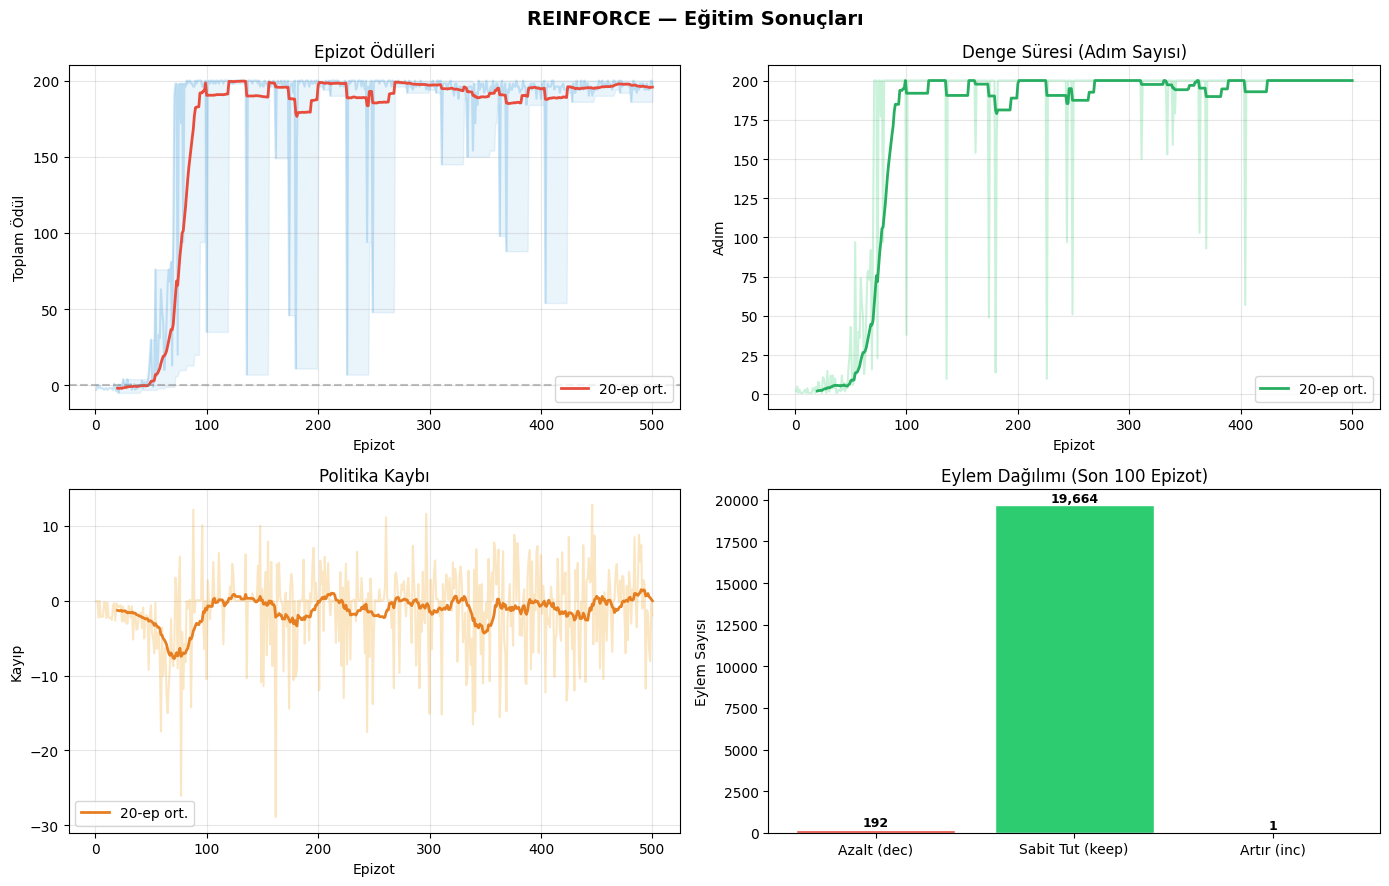

In [18]:
# ── 5.1 Eğitim Özet Grafikleri ──
W = 20
ep_x = range(1, NUM_EPISODES + 1)
sm_r = pd.Series(history['rewards']).rolling(W).mean()
sm_l = pd.Series(history['lengths']).rolling(W).mean()
sm_loss = pd.Series(history['losses']).rolling(W).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('REINFORCE — Eğitim Sonuçları', fontsize=14, fontweight='bold')

# Ödül
axes[0,0].plot(ep_x, history['rewards'], alpha=0.25, color='#3498DB')
axes[0,0].plot(ep_x, sm_r, color='#E74C3C', linewidth=2, label=f'{W}-ep ort.')
axes[0,0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0,0].fill_between(ep_x,
    pd.Series(history['rewards']).rolling(W).min(),
    pd.Series(history['rewards']).rolling(W).max(),
    alpha=0.1, color='#3498DB')
axes[0,0].set_title('Epizot Ödülleri')
axes[0,0].set_xlabel('Epizot')
axes[0,0].set_ylabel('Toplam Ödül')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Denge süresi
axes[0,1].plot(ep_x, history['lengths'], alpha=0.25, color='#2ECC71')
axes[0,1].plot(ep_x, sm_l, color='#27AE60', linewidth=2, label=f'{W}-ep ort.')
axes[0,1].set_title('Denge Süresi (Adım Sayısı)')
axes[0,1].set_xlabel('Epizot')
axes[0,1].set_ylabel('Adım')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Kayıp
axes[1,0].plot(ep_x, history['losses'], alpha=0.25, color='#F39C12')
axes[1,0].plot(ep_x, sm_loss, color='#E67E22', linewidth=2, label=f'{W}-ep ort.')
axes[1,0].set_title('Politika Kaybı')
axes[1,0].set_xlabel('Epizot')
axes[1,0].set_ylabel('Kayıp')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Eylem dağılımı (son 100 ep)
last_acts = [a for ep_acts in history['actions'][-100:] for a in ep_acts]
act_counts = [last_acts.count(i) for i in range(NUM_ACTIONS)]
bar_colors = ['#E74C3C', '#2ECC71', '#3498DB']
bars = axes[1,1].bar(ACTION_NAMES, act_counts, color=bar_colors, edgecolor='white')
for bar, cnt in zip(bars, act_counts):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + max(act_counts)*0.01,
                   f'{cnt:,}', ha='center', fontweight='bold', fontsize=9)
axes[1,1].set_title('Eylem Dağılımı (Son 100 Epizot)')
axes[1,1].set_ylabel('Eylem Sayısı')

plt.tight_layout()
plt.savefig('results_01_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── 5.2 Plotly İnteraktif Grafik ──
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Epizot Ödülleri (İnteraktif)', 'Denge Süresi (İnteraktif)'])

fig.add_trace(go.Scatter(x=list(ep_x), y=history['rewards'],
    mode='lines', name='Ham', line=dict(color='lightblue', width=1), opacity=0.5), row=1, col=1)
fig.add_trace(go.Scatter(x=list(ep_x), y=sm_r.tolist(),
    mode='lines', name='Ort. Ödül', line=dict(color='red', width=2.5)), row=1, col=1)

fig.add_trace(go.Scatter(x=list(ep_x), y=history['lengths'],
    mode='lines', name='Ham Süre', line=dict(color='lightgreen', width=1), opacity=0.5), row=1, col=2)
fig.add_trace(go.Scatter(x=list(ep_x), y=sm_l.tolist(),
    mode='lines', name='Ort. Süre', line=dict(color='darkgreen', width=2.5)), row=1, col=2)

fig.update_layout(title='REINFORCE İnteraktif Eğitim Takibi',
                  height=420, hovermode='x unified')
fig.update_xaxes(title_text='Epizot')
fig.show()

Örnek epizot — 200 adım | Toplam ödül: 200.00


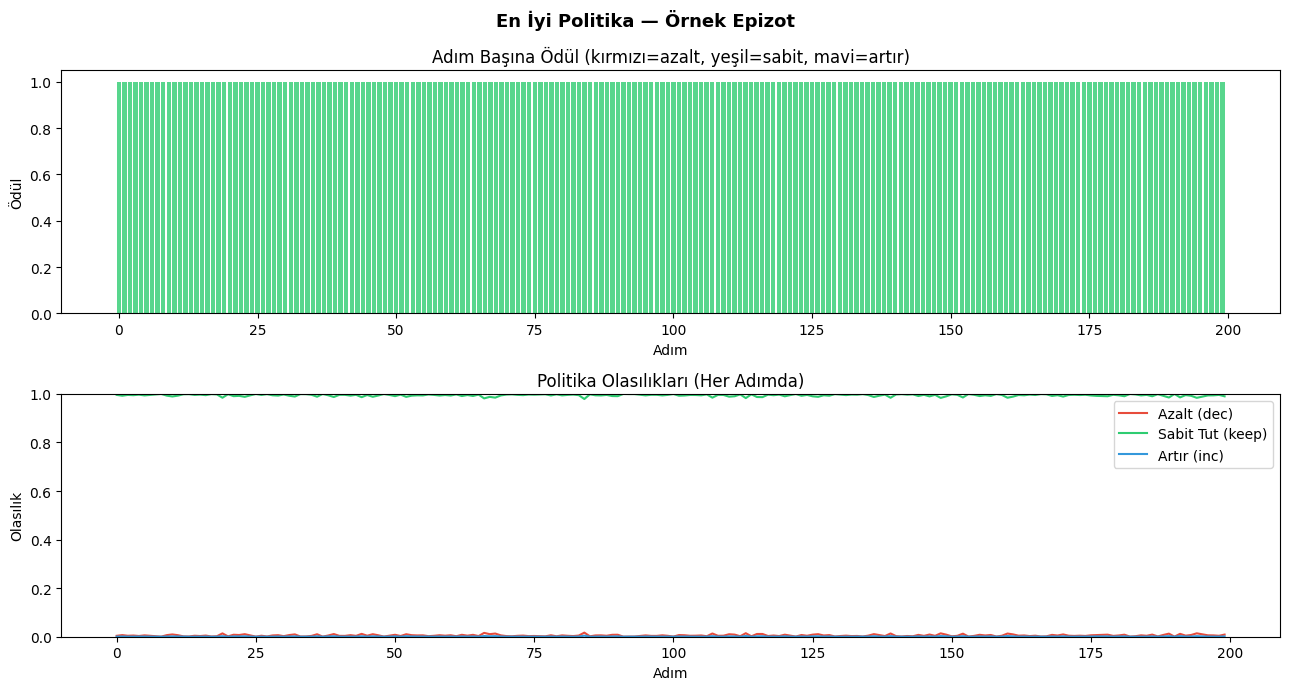

In [20]:
# ── 5.3 Simülasyon Örneği — En iyi politika ile 1 epizot ──
policy.load_state_dict(torch.load('best_policy.pth', map_location=device))
policy.eval()

state, _ = env.reset()
step_rewards, step_actions, step_probs = [], [], []

with torch.no_grad():
    done = False
    while not done:
        st = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs = policy(st).cpu().numpy()[0]
        action = np.argmax(probs)
        state, reward, terminated, truncated, _ = env.step(action)
        step_rewards.append(reward)
        step_actions.append(action)
        step_probs.append(probs)
        done = terminated or truncated

print(f'Örnek epizot — {len(step_rewards)} adım | Toplam ödül: {sum(step_rewards):.2f}')

# Adım adım görsel
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
steps = range(len(step_rewards))

colors_map = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
bar_colors = [colors_map[a] for a in step_actions]
axes[0].bar(steps, step_rewards, color=bar_colors, edgecolor='none', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_title('Adım Başına Ödül (kırmızı=azalt, yeşil=sabit, mavi=artır)')
axes[0].set_ylabel('Ödül')
axes[0].set_xlabel('Adım')

prob_arr = np.array(step_probs)
for i, (name, col) in enumerate(zip(ACTION_NAMES, ['#E74C3C','#2ECC71','#3498DB'])):
    axes[1].plot(steps, prob_arr[:, i], label=name, color=col, linewidth=1.5)
axes[1].set_title('Politika Olasılıkları (Her Adımda)')
axes[1].set_ylabel('Olasılık')
axes[1].set_xlabel('Adım')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle('En İyi Politika — Örnek Epizot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_02_sample_episode.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── 5.4 Klinik Değerlendirme Metrikleri ──
policy.eval()
test_n = 100
test_rewards, test_lengths, test_act_dist = [], [], []

with torch.no_grad():
    for _ in range(test_n):
        _, rewards, _, actions = run_episode(env, policy)
        test_rewards.append(sum(rewards))
        test_lengths.append(len(rewards))
        test_act_dist.extend(actions)

print('=' * 50)
print('       KLİNİK DEĞERLENDİRME METRİKLERİ')
print('=' * 50)
print(f'Test epizot sayısı   : {test_n}')
print(f'Ortalama Ödül        : {np.mean(test_rewards):+.3f} ± {np.std(test_rewards):.3f}')
print(f'Medyan Ödül          : {np.median(test_rewards):+.3f}')
print(f'Ort. Denge Süresi    : {np.mean(test_lengths):.1f} ± {np.std(test_lengths):.1f} adım')
print(f'Min / Maks Ödül      : {min(test_rewards):.2f} / {max(test_rewards):.2f}')
print()
for i, name in enumerate(ACTION_NAMES):
    cnt = test_act_dist.count(i)
    pct = cnt / len(test_act_dist) * 100
    print(f'  {name:20s}: {cnt:5d} ({pct:.1f}%)')
print('=' * 50)

       KLİNİK DEĞERLENDİRME METRİKLERİ
Test epizot sayısı   : 100
Ortalama Ödül        : +181.310 ± 47.130
Medyan Ödül          : +198.000
Ort. Denge Süresi    : 183.4 ± 46.7 adım
Min / Maks Ödül      : -2.00 / 200.00

  Azalt (dec)         :    82 (0.4%)
  Sabit Tut (keep)    : 18245 (99.5%)
  Artır (inc)         :    16 (0.1%)


## 6 — Kaydetme ve İndirme

In [22]:
# Model checkpoint
torch.save({
    'model_state_dict'    : policy.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'episode_rewards'     : history['rewards'],
    'episode_lengths'     : history['lengths'],
    'state_dim'           : STATE_DIM,
    'num_actions'         : NUM_ACTIONS,
    'best_reward'         : BEST_REWARD,
}, 'reinforce_final.pth')
print('Model kaydedildi: reinforce_final.pth')

# ZIP
out_files = [
    'reinforce_final.pth',
    'best_policy.pth',
    'results_01_training.png',
    'results_02_sample_episode.png',
]

with zipfile.ZipFile('ISE427_model_ciktilari.zip', 'w') as zf:
    for f in out_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  + {f}')

from google.colab import files
files.download('ISE427_model_ciktilari.zip')
print('\n ZIP indirildi.')

Model kaydedildi: reinforce_final.pth
  + reinforce_final.pth
  + best_policy.pth
  + results_01_training.png
  + results_02_sample_episode.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 ZIP indirildi.


---
## 📝 7 — Tartışma ve Klinik Yorum

### Simülasyon Ortamı Tasarımı
OpenAI Gymnasium'dan ilham alınan `MedicalEnv` ortamında CartPole'un denge mantığı tıbbi senaryoya uyarlanmıştır:
- **Direğin açısı** → Glukoz sapması (hedef aralıktan uzaklık)
- **Düşme koşulu** → Şiddetli hiperglisemi (r ≤ -2)

### REINFORCE Algoritması
Policy Gradient yöntemi; mevcut duruma bakarak her üç eylemin (azalt/sabit/artır) uzun vadeli getiriye katkısını öğrenir. Entropi bonusu ile keşif–sömürü dengesi sağlanmıştır.

### Etik ve Güvenlik
- Tüm keşif gerçek hastalar yerine simülasyonda yapılmıştır (**Offline RL**)
- Hipoglisemi cezası (-1.0), hiperglisemi cezasından (-2.0) küçük tutulmuştur → **Güvenlik önceliği**
- Art arda doz artırımına ek ceza (-0.1) → **Aşırı doz koruması**
- Klinik ortama geçiş için kapsamlı prospektif doğrulama çalışmaları gereklidir

### Kısıtlamalar
- Gerçek fizyolojik dinamikler çok daha karmaşıktır
- Bireysel farmakodinamik farklılıklar modelde tam yansıtılamamaktadır
- Kaggle veri setinin klinik temsil gücü sınırlıdır